<a href="https://colab.research.google.com/github/Lexuanthangutc/Cell-Detection/blob/main/PSPNET_Cell_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install -q torchmetrics
# !pip3 install -q segmentation-models-pytorch
# !pip3 install -q albumentations

# Connect Google Drive

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Packages

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageColor
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms.functional as F_trans
from torchvision.transforms.v2 import functional as F_trans_v2
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

import torchmetrics
from torchmetrics import Dice, JaccardIndex

# import albumentations as A
# from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor


import os
from tqdm import tqdm
from glob import glob # read and close image in folder


In [4]:
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    
seed_everything(42)

# Preprocessing

# General information

In [41]:
pwd

'/kaggle/working'

In [5]:
Data_dir = "../input"
images_dir = "../input/P01_images"
masks_dir = "../input/P01_masks"
annotations_dir = "../input/P01_object_detection"

CELL_CLASSES = [
    "Marcophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris",
    "Basophil",
]

# Define color to class index mapping
label_hotcode_colors = {
    (28, 230, 255): 1,  # Macrophage/Monocyte
    (255, 52, 255): 2,  # Neutrophil
    (255, 74, 70): 3,  # Eosinophil
    (0, 137, 65): 4,  # Lymphocyte
    (0, 111, 166): 5,  # Unknown cell/Debris
    (163, 0, 89): 6,   # Basophil
}

label_colors = {
    "Marcophage/Monocyte": (28, 230, 255),
    "Neutrophil" : (255, 52, 255), 
    "Eosinophil" : (255, 74, 70), 
    "Lymphocyte" : (0, 137, 65),
    "Unknown cell/Debris": (0, 111, 166),
    "Basophil": (163, 0, 89), 
}

# Get list of all images name

In [6]:
import os

# List all files in the folder
image_names = [os.path.splitext(f)[0] for f in os.listdir(images_dir) if f.endswith('.png')]
image_names[:10]

['P01_12_19',
 'P01_17_17',
 'P01_6_26',
 'P01_21_10',
 'P01_6_21',
 'P01_3_22',
 'P01_2_24',
 'P01_18_21',
 'P01_3_24',
 'P01_15_19']

In [7]:
plt.rcParams["savefig.bbox"] = 'tight'
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F_trans.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])


In [8]:
import json
import random
idx = random.randint(0,90)
def extract_box(annotation_folder_path, idx):
    # Extract boxes and list of objects in an image
    # boxes: return a list of boxes in tensor format [N x 4]
    # labels_list: return a list of labels correleration with boxes [N x 1]
    anonotation_file_path = os.path.join(annotation_folder_path,'{}.json'.format(image_names[idx]))
    annotation_file = open(anonotation_file_path)
    data_json = json.load(annotation_file)
    boxes_list = []
    labels_list = []
    colors_list = []
    for obj in data_json['bounding_boxes']:
        box = torch.tensor(obj['bounding_box'])
        boxes_list.append(box)
        label = obj['name']
        labels_list.append(label)
        
        # Find the corresponding color for the label
        assigned_color = label_colors.get(label)  # Default to black (0, 0, 0) if label not found
        colors_list.append(assigned_color)
        
    boxes = torch.stack(boxes_list)
    assert len(boxes) == len(labels_list), print(f"There is different of length bboxes {len(boxes)} and labels list {len(labels_list)}")
    assert len(boxes) == len(colors_list), print(f"There is different of length bboxes {len(boxes)} and colors list {len(colors_list)}")
    assert len(labels_list) == len(colors_list), print(f"There is different lenth of colors list {len(labels_list)} and labels list {len(colors_list)}")
#     print(len(boxes), len(labels_list), len(colors_list)) # use when you need check the length
    return boxes, labels_list, colors_list

# test
bboxes, labels_list, colors_list = extract_box(annotations_dir, idx)
# bboxes, labels_list, colors_list

tensor([[ 210,  253,  296,  339],
        [  73,  144,  160,  226],
        [ 574,    7,  644,   80],
        [ 253,  155,  347,  247],
        [ 210,  253,  296,  339],
        [  73,  144,  160,  226],
        [  73,  144,  160,  226],
        [ 574,    7,  644,   80],
        [ 626,    0,  694,   59],
        [ 917,  354, 1024,  480],
        [ 286,  464,  360,  538],
        [ 724,  164,  796,  241],
        [ 767,  240,  842,  314],
        [ 772,  767,  864,  880],
        [ 731,  830,  885,  987],
        [  17,  851,   19,  855],
        [   0,  761,   69,  847],
        [   0,  456,   71,  544],
        [ 851,  562,  933,  660],
        [ 919,  620, 1005,  702],
        [ 681,  527,  772,  619],
        [ 286,  464,  360,  538],
        [ 724,  164,  796,  241],
        [ 333,  425,  397,  495],
        [ 363,  468,  427,  535],
        [ 233,  329,  293,  393],
        [ 632,  145,  700,  212],
        [ 809,  593,  854,  643],
        [ 654,  866,  718,  919],
        [ 199,

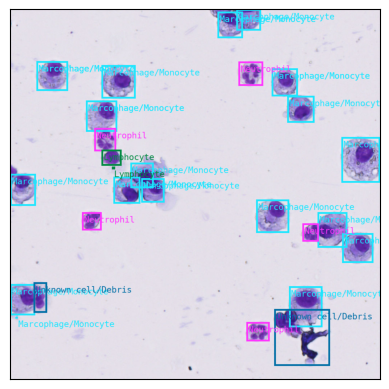

In [9]:
import random
idx = random.randint(0,90)
def visualization_object(images_dir, annotations_dir, idx):
    # Read the image
    image_path = os.path.join(images_dir,'{}.png'.format(image_names[idx]))
    image = read_image(image_path)
    bboxes, labels_list, colors_list = extract_box(annotations_dir, idx)
    print(bboxes, labels_list, colors_list)
    result = draw_bounding_boxes(image,bboxes,labels = labels_list, colors= colors_list, width=5, font = "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf", font_size = 24)
    show(result)
    
visualization_object(images_dir, annotations_dir, idx)

# Dataset

The dataset should be format in following instruction: [Pytorch Dataset](https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

In [50]:
class CellDataset(Dataset):
    def __init__(self, images_dir, annotations_dir, transform=None):
        """
        Args:
            images_dir (string): Path to the directory containing images.
            annotations_dir (string): Path to the directory containing corresponding annotation.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.annotations_dir = annotations_dir
        self.transform = transform
        self.image_ids = [os.path.splitext(f)[0] for f in os.listdir(images_dir) if f.endswith('.png')]

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.image_ids)

    def __getitem__(self, idx):
        """
        Generate one sample of data.
        """
        # Build paths for image and annotation
        annotation_path = os.path.join(self.annotations_dir, '{}.json'.format(self.image_ids[idx]))
        image_path = os.path.join(self.images_dir, '{}.png'.format(self.image_ids[idx]))
        
        # Check if the annotation file exists
        if not os.path.exists(annotation_path):
#             print(f"Annotation for image {annotation_path} not found, skipping.")
            # Skip the image and try the next one
            return self.__getitem__((idx + 1) % len(self))
                                    
        # Extract info of object
        bboxes, labels_list, colors_list = extract_box(self.annotations_dir,idx)
        
        labels = [label_hotcode_colors[color] for color in colors_list]
        
        # Load image
        image = read_image(image_path)
        
        # Calculate areas
        boxes = tv_tensors.BoundingBoxes(bboxes, format="XYXY", canvas_size=F_trans_v2.get_size(image))
        labels = torch.tensor(labels)
        image_id = torch.tensor(idx).unsqueeze(0)        
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        # Wrap sample and targets into torchvision tv_tensors
        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F_trans_v2.get_size(image))
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd
        
        # Apply transformations
        if self.transform:
            original_size = F_trans_v2.get_size(image)  # Get the original size of the image before transform
            image, target = self.transform(image, target)
            
        return image, target

In [51]:
from torchvision.transforms import v2
# Define augmentations using Albumentations
def get_transform(train=True):
    trainsize = 256
    if train:
        transforms = v2.Compose([
                v2.ToImage(),
                v2.Resize((trainsize, trainsize),interpolation=F_trans_v2.InterpolationMode.NEAREST),
                v2.RandomPhotometricDistort(p=1),
#                 v2.RandomZoomOut(fill={tv_tensors.Image: (123, 117, 104), "others": 0}),
#                 v2.RandomIoUCrop(),
                v2.RandomHorizontalFlip(p=1),
                v2.SanitizeBoundingBoxes(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
            ])
    else:
        transforms = v2.Compose([
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
        ])

    return transforms

def collate_fn(batch):
    return tuple(zip(*batch))


In [52]:
# Initialize dataset
dataset = CellDataset(images_dir,annotations_dir,transform=get_transform(train=True))
print(len(dataset))

91


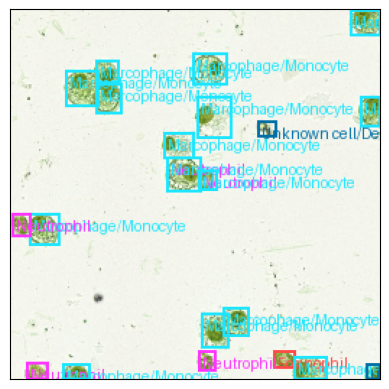

In [53]:
# Reverse the label_colors dictionary for converting integer labels back to names
class_names = {
    1: "Marcophage/Monocyte",
    2: "Neutrophil",
    3: "Eosinophil",
    4: "Lymphocyte",
    5: "Unknown cell/Debris",
    6: "Basophil"
}

from torchvision import tv_tensors
idx = random.randint(1, 90) 
img, target = dataset.__getitem__(idx)


# convert format for draw_bounding_boxes functino in pytorch
image = (img * 255).type(torch.uint8).squeeze()
boxes = target['boxes']
labels = target['labels'].tolist()

# Convert labels (integers) back to names and get their corresponding colors
label_names = [class_names[label] for label in labels]
colors = [label_colors[class_names[label]] for label in labels]

result = draw_bounding_boxes(image, boxes,label_names,colors=colors, width=2)
show(result) 

In [54]:
# Assume your dataset class is defined as SUTCrackDataset
# Define the dataset
data = CellDataset(images_dir=images_dir, 
                       annotations_dir=annotations_dir, 
                       transform=get_transform(train=True))

# Define the size of each split
train_size = 0.7 # 60% for training
val_size = 0.3    # 20% for validation
# test_size = 0.01  # Remaining for testing (20%)

# Use random_split to split the dataset
train_dataset, val_dataset, test_dataset = random_split(data, 
                                                        [train_size, val_size, 0], 
                                                        generator=torch.Generator().manual_seed(42))

# Create DataLoaders for each split
BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True, 
                          num_workers=4, 
                          collate_fn=collate_fn)

val_loader = DataLoader(val_dataset, 
                        batch_size=BATCH_SIZE, 
                        shuffle=False, 
                        num_workers=4, 
                        collate_fn=collate_fn)

# test_loader = DataLoader(test_dataset, 
#                          batch_size=BATCH_SIZE, 
#                          shuffle=False, 
#                          num_workers=4, 
#                          collate_fn=collate_fn)

# Test the loaders (optional)
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")
# print(f"Test dataset size: {len(test_loader.dataset)}")

Train dataset size: 64
Validation dataset size: 27


/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataset.py:473: UserWarning: Length of split at index 2 is 0. This might result in an empty dataset.
  warnings.warn(


# Model

In [55]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# load a model pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# replace the classifier with a new one, that has
# num_classes which is user-defined
num_classes = 7  # 6 class + background
# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
# print(model)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [56]:
# Step 3: Move model to the correct device (GPU if available)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# Step 4: Set up optimizer and learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [57]:
class Averager:      ##Return the average loss 
    def __init__(self):
        self.current_total = 0.0
        self.iterations = 0.0

    def send(self, value):
        self.current_total += value
        self.iterations += 1

    @property
    def value(self):
        if self.iterations == 0:
            return 0
        else:
            return 1.0 * self.current_total / self.iterations

    def reset(self):
        self.current_total = 0.0
        self.iterations = 0.0

In [59]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchmetrics.detection.iou import IntersectionOverUnion as IoU

# Define History class to store training and validation history
class History:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.val_IoU = []

def train_model(model, num_epochs, train_loader, val_loader, device, optimizer):
    history = History()
    
    # Initialize torchmetrics for IoU
    iou_metric = IoU()  # Assuming 1 class + background

    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        
        # Training phase
        for images, targets in train_loader:
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

            # Forward pass
            outputs = model(images, targets)
            losses = sum(loss for loss in outputs.values())
        
            # Backward pass and optimize
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        history.train_loss.append(total_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {history.train_loss[-1]:.4f}")

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        total_iou = 0.0  # Store IoU for each validation batch
        num_samples = 0  # Number of samples for averaging IoU

        with torch.no_grad():
            for images, targets in val_loader:
                images = [image.to(device) for image in images]
                targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

                # Forward pass (no targets during inference)
                outputs = model(images)
#                 print(outputs)
                # Prepare predictions and ground truth for IoU calculation
                for i in range(len(images)):
                    pred_boxes = outputs[i]['boxes'].cpu()
                    target_boxes = targets[i]['boxes'].cpu()

                    # Format as list of dictionaries
                    pred_dict = [{"boxes": pred_boxes, "labels": outputs[i]['labels'].cpu()}]
                    target_dict = [{"boxes": target_boxes, "labels": targets[i]['labels'].cpu()}]

                    # Update IoU metric
                    iou_metric.update(pred_dict, target_dict)

                num_samples += len(images)

        # Compute the average IoU for this epoch
        avg_iou = iou_metric.compute()
        
        # Extract relevant IoU value from the dictionary
        avg_iou_value = avg_iou["iou"].item() if "iou" in avg_iou else avg_iou["mean_iou"].item()
        
        history.val_IoU.append(avg_iou_value)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Validation IoU: {avg_iou_value:.4f}")

        # Reset the IoU metric for the next epoch
        iou_metric.reset()

    return history

# Let's train it for 2 epochs as an example
num_epochs = 100

# Example usage
history = train_model(model, num_epochs, train_loader, val_loader, device, optimizer)

Epoch 1/100, Train Loss: 2.0276
Epoch 1/100, Validation IoU: 0.0258
Epoch 2/100, Train Loss: 1.8934
Epoch 2/100, Validation IoU: 0.0238
Epoch 3/100, Train Loss: 1.7704
Epoch 3/100, Validation IoU: 0.0267
Epoch 4/100, Train Loss: 1.5859
Epoch 4/100, Validation IoU: 0.0256
Epoch 5/100, Train Loss: 1.4849
Epoch 5/100, Validation IoU: 0.0280
Epoch 6/100, Train Loss: 1.3439
Epoch 6/100, Validation IoU: 0.0294
Epoch 7/100, Train Loss: 1.2235
Epoch 7/100, Validation IoU: 0.0273
Epoch 8/100, Train Loss: 1.1930
Epoch 8/100, Validation IoU: 0.0312
Epoch 9/100, Train Loss: 1.1242
Epoch 9/100, Validation IoU: 0.0313
Epoch 10/100, Train Loss: 1.0577
Epoch 10/100, Validation IoU: 0.0313
Epoch 11/100, Train Loss: 0.9975
Epoch 11/100, Validation IoU: 0.0298
Epoch 12/100, Train Loss: 0.9596
Epoch 12/100, Validation IoU: 0.0326
Epoch 13/100, Train Loss: 0.9506
Epoch 13/100, Validation IoU: 0.0336
Epoch 14/100, Train Loss: 0.9236
Epoch 14/100, Validation IoU: 0.0343
Epoch 15/100, Train Loss: 0.8353
Epoch

# Visualization of results

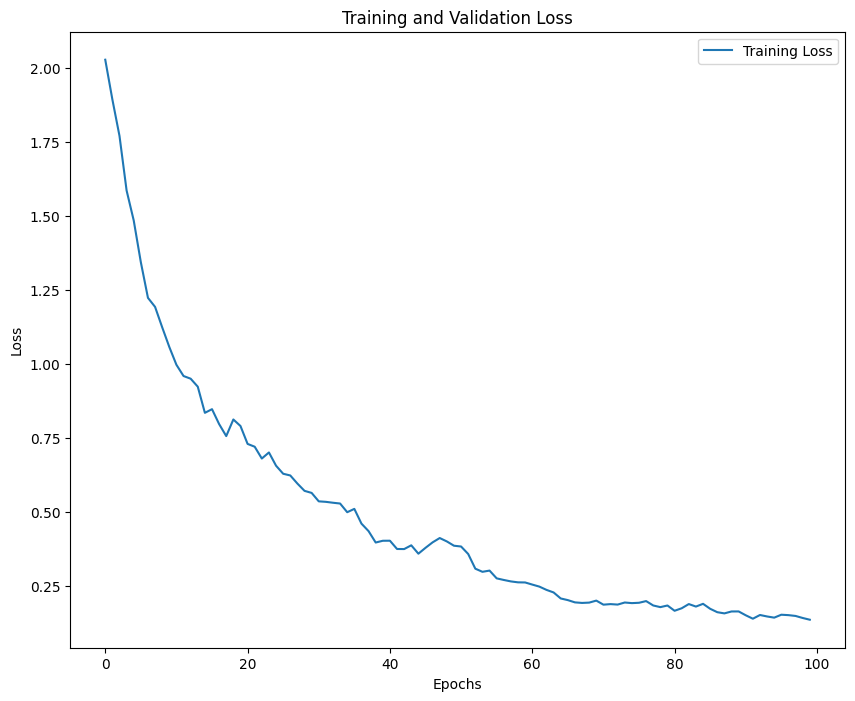

In [60]:
# Plotting training/validation loss and accuracy
plt.figure(figsize=(10, 8))

# Plot training and validation loss

plt.plot(history.train_loss, label='Training Loss')
# plt.plot(History['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.show()

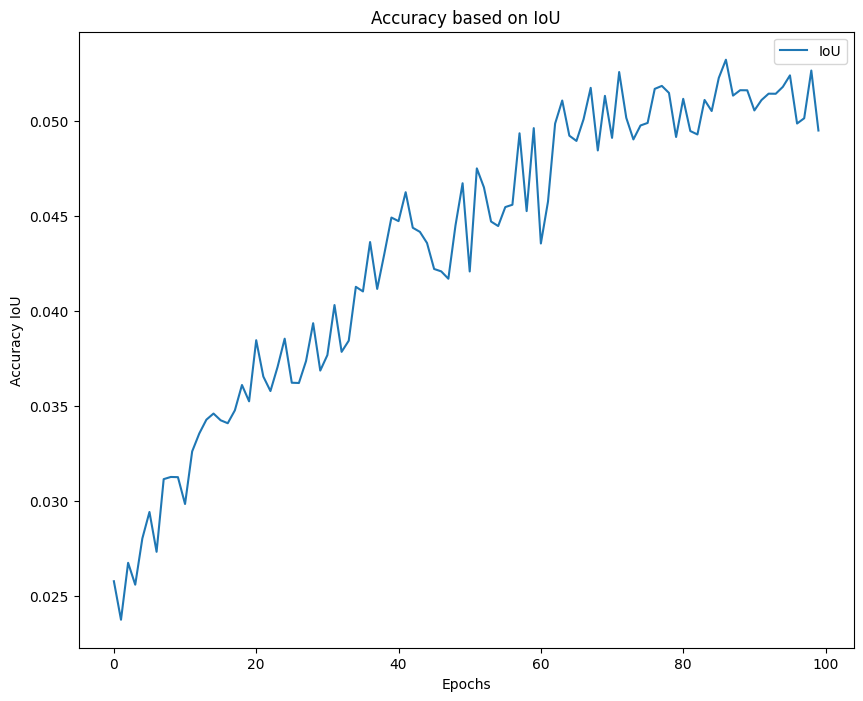

In [61]:
# Plotting training/validation loss and accuracy
plt.figure(figsize=(10, 8))

# Plot training and validation loss

plt.plot(history.val_IoU, label='IoU')
# plt.plot(History['val_loss'], label='Validation Loss')
plt.title('Accuracy based on IoU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy IoU')
plt.legend()

# Show the plots
plt.show()

[{'boxes': tensor([[4.1891e+01, 4.1543e+00, 6.4455e+01, 2.7388e+01],
        [6.0231e+01, 9.8029e+01, 8.3012e+01, 1.2270e+02],
        [5.1101e+01, 2.2947e+02, 7.2541e+01, 2.5088e+02],
        [7.8128e+01, 1.9795e+01, 9.9335e+01, 4.2263e+01],
        [2.7204e+00, 1.4589e+02, 2.3340e+01, 1.6610e+02],
        [5.7109e+01, 1.9305e+02, 7.8208e+01, 2.1548e+02],
        [1.9609e+02, 0.0000e+00, 2.1719e+02, 2.1839e+01],
        [2.2957e+02, 3.4779e+01, 2.4925e+02, 5.3385e+01],
        [7.6457e+01, 2.0472e+02, 9.5214e+01, 2.2366e+02],
        [3.3495e+01, 1.0683e+02, 4.8937e+01, 1.2289e+02],
        [1.0131e+02, 4.6779e+01, 1.2234e+02, 6.9412e+01],
        [8.4524e+01, 2.1724e+02, 1.0491e+02, 2.3621e+02],
        [2.1674e+02, 2.3234e+02, 2.3481e+02, 2.4930e+02],
        [2.3733e+02, 6.6833e+01, 2.5110e+02, 8.1467e+01],
        [6.8355e+00, 6.5992e+00, 2.7062e+01, 2.8966e+01],
        [1.5602e+00, 2.7624e+01, 2.4385e+01, 5.3466e+01],
        [1.6463e+02, 1.9058e+02, 1.7869e+02, 2.0598e+02],
   

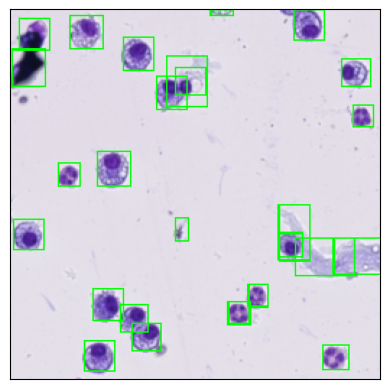

In [64]:
model.eval()

# Read the image
image_path = '../input/P01_images/P01_10_17.png'
image = read_image(image_path)
# print(image.unsqueeze(0).shape)

# Resize and normalize the image to match model's expected input size
transform = v2.Compose([
    v2.Resize((256, 256)),  # Resize to 256x256
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0,0,0], std=[1,1,1])
])

img = transform(image)
# print(img.shape)
image_tensor = img.to(device)
# print(image_tensor.shape)
# Inference
with torch.no_grad():
    target_pred = model(image_tensor.unsqueeze(0))
print(target_pred)
# # print((img_pred * 255).type(torch.uint8).squeeze().shape)
result = draw_bounding_boxes((image_tensor * 255).type(torch.uint8).squeeze(), target_pred[0]['boxes'], 
                                    colors=(0, 255, 0), width=1)
show(result) 